In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# !pip install torch transformers accelerate

In [ ]:
import sys
import os

# Add the geometric_interpretability_LLMs directory (parent of examples) to Python path
# For Jupyter notebooks, use relative path since __file__ is not available
sys.path.insert(0, os.path.abspath('../..'))

import matplotlib.pyplot as plt
import numpy as np

In [5]:
from src.models.llm_interface import LlamaInterface

llm = LlamaInterface("llama-3.1-8b")

# llm = LlamaInterface("llama-3.2-1b")

# Random walk sequence on the graph
sequence = ["apple", "bird", "milk", "sand", "sun", "plane"]

# Get layer 26 representations (as in the paper)
result = llm.forward_with_context(sequence, layer_idx=15)

# result['layer_representations'] shape: (seq_len, hidden_dim)
# Apply PCA to visualize emergent graph structure

Loading llama-3.1-8b on cuda...


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Model loaded successfully! Layers: 32
Hidden states: 33 layers, each shape: torch.Size([1, 12, 4096])


In [159]:
#Code to pass a random walk with size n to the LLM and get the residual stream
import networkx as nx
import numpy as np
from src.models.llm_interface import LlamaInterface

# --- Configuration ---
WALK_LENGTH = 4000
GRID_SIZE = 4 
LAYER_IDX = 26  # Layer to extract (paper uses layer 26 for Llama-3.1-8B)

# --- Create concept vocabulary (25 common words for 5x5 grid) ---
# CONCEPTS = [
#     "apple", "bird", "car", "egg",
#     "house", "milk", "plane", "opera",
#     "box", "sand", "sun", "mango",
#     "rock", "math", "code", "phone",
# ]

CONCEPTS = [
    "A", "B", "C", "D",
    "E", "F", "G", "H",
    "I", "J", "K", "L",
    "M", "N", "O", "P",
]

# --- Create grid graph ---
n = GRID_SIZE
graph = nx.grid_2d_graph(n, n)

# Convert 2D coordinates to indices
mapping = {(x, y): y * n + x for x, y in graph.nodes()}
graph = nx.relabel_nodes(graph, mapping)

print(f"Grid graph: {graph.number_of_nodes()} nodes, {graph.number_of_edges()} edges")
print(f"Concepts: {CONCEPTS[:graph.number_of_nodes()]}")

# --- Generate random walk ---
def generate_random_walk(graph, length, start_node=None):
    """Generate a random walk on the graph."""
    nodes = list(graph.nodes())
    if start_node is None:
        start_node = np.random.choice(nodes)
    
    walk = [start_node]
    current = start_node
    
    for _ in range(length - 1):
        neighbors = list(graph.neighbors(current))
        current = np.random.choice(neighbors)
        walk.append(current)
    
    return walk

# Generate random walk
random_walk = generate_random_walk(graph, WALK_LENGTH)
print(f"\nRandom walk length: {len(random_walk)}")
print(f"First 20 nodes: {random_walk[:20]}")

# Convert node indices to concept words
walk_concepts = [CONCEPTS[node] for node in random_walk]
print(f"First 20 concepts: {walk_concepts[:20]}")


Grid graph: 16 nodes, 24 edges
Concepts: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P']

Random walk length: 4000
First 20 nodes: [1, 2, 3, 7, 3, 7, 6, 5, 6, 10, 6, 10, 6, 2, 6, 7, 3, 7, 11, 7]
First 20 concepts: ['B', 'C', 'D', 'H', 'D', 'H', 'G', 'F', 'G', 'K', 'G', 'K', 'G', 'C', 'G', 'H', 'D', 'H', 'L', 'H']


In [160]:
# --- Pass random walk to LLM and get layer 26 residual stream ---

# Initialize Llama model (use the already loaded one if available, or load fresh)
# For layer 26, we need at least a 32-layer model (Llama-3-8B or Llama-3.1-8B)
if 'llm' not in dir() or llm.num_layers < LAYER_IDX:
    print(f"Loading model with at least {LAYER_IDX} layers...")
    llm = LlamaInterface("llama-3.1-8b")  # 32 layers
else:
    print(f"Using existing model with {llm.num_layers} layers")

# Adjust layer index if model has fewer layers
actual_layer = min(LAYER_IDX, llm.num_layers)
print(f"Extracting from layer {actual_layer} (model has {llm.num_layers} layers)")

# Pass the random walk sequence to the model
print(f"\nProcessing {len(walk_concepts)} tokens...")


Using existing model with 32 layers
Extracting from layer 26 (model has 32 layers)

Processing 4000 tokens...


In [161]:
walk_concepts[:10]

['B', 'C', 'D', 'H', 'D', 'H', 'G', 'F', 'G', 'K']

In [162]:
result = llm.forward_with_context(walk_concepts, layer_idx=actual_layer)

# Extract the residual stream activations
residual_stream = result['layer_representations']
tokens = result['tokens']

print(f"\n--- Results ---")
print(f"Residual stream shape: {residual_stream.shape}")
print(f"  - Sequence length: {residual_stream.shape[0]} tokens")
print(f"  - Hidden dimension: {residual_stream.shape[1]}")
print(f"\nFirst 10 tokens: {tokens[:10]}")
print(f"Last 10 tokens: {tokens[-10:]}")

Hidden states: 33 layers, each shape: torch.Size([1, 4001, 4096])

--- Results ---
Residual stream shape: (4001, 4096)
  - Sequence length: 4001 tokens
  - Hidden dimension: 4096

First 10 tokens: ['<|begin_of_text|>', 'B', 'ĠC', 'ĠD', 'ĠH', 'ĠD', 'ĠH', 'ĠG', 'ĠF', 'ĠG']
Last 10 tokens: ['ĠB', 'ĠA', 'ĠE', 'ĠI', 'ĠE', 'ĠF', 'ĠJ', 'ĠN', 'ĠJ', 'ĠF']


In [169]:
result['hidden_states'].shape

(33, 4001, 4096)

In [164]:
residual_stream.shape

(4001, 4096)

In [165]:
# --- Compute mean representation per concept using sliding window ---
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

WINDOW_SIZE = 50

# Compute sliding window mean for each token position
# residual_stream has shape (num_tokens, hidden_dim)
print(f"Computing sliding window means (window size: {WINDOW_SIZE})...")

num_tokens = residual_stream.shape[0]
sliding_window_means = np.zeros_like(residual_stream)

for i in range(num_tokens):
    # Take mean of last WINDOW_SIZE activations (or all preceding if less)
    start_idx = max(0, i - WINDOW_SIZE + 1)
    sliding_window_means[i] = residual_stream[start_idx:i+1].mean(axis=0)

print(f"Sliding window means shape: {sliding_window_means.shape}")

# Map tokens back to concepts and compute mean representation per concept
# tokens[0] is <|begin_of_text|>, then tokens[1:] correspond to walk_concepts

# Create mapping from concept to token positions
concept_positions = {concept: [] for concept in CONCEPTS[:graph.number_of_nodes()]}

# Skip the first token (BOS token), map remaining to concepts
for i, concept in enumerate(walk_concepts):
    token_idx = i + 1  # +1 because of BOS token
    if token_idx < num_tokens:
        concept_positions[concept].append(token_idx)

# Compute mean sliding window representation per concept (using only last 1000 tokens)
print("Computing mean representation per concept from sliding window means (last 1000 only)...")
LAST_N = 4000
cutoff_idx = max(0, num_tokens - LAST_N)
concept_means = {}
for concept in CONCEPTS[:graph.number_of_nodes()]:
    positions = concept_positions[concept]
    # Filter to only include positions in the last 1000 tokens
    positions = [p for p in positions if p >= cutoff_idx]
    if positions:
        concept_means[concept] = sliding_window_means[positions].mean(axis=0)
    else:
        print(f"Warning: No positions found for concept '{concept}' in last {LAST_N} tokens")
        concept_means[concept] = np.zeros(residual_stream.shape[1])

Computing sliding window means (window size: 50)...
Sliding window means shape: (4001, 4096)
Computing mean representation per concept from sliding window means (last 1000 only)...


In [166]:
# --- Apply PCA on concept means ---
from sklearn.decomposition import PCA

# Convert concept_means dict to array (preserving concept order)
concept_names = CONCEPTS[:graph.number_of_nodes()]
representations = np.array([concept_means[concept] for concept in concept_names])
print(f"Representations shape: {representations.shape}")  # (num_concepts, hidden_dim)

# Apply PCA to reduce to 2D for visualization
pca = PCA(n_components=2)
pca_result = pca.fit_transform(representations)

print(f"PCA result shape: {pca_result.shape}")
print(f"Explained variance ratio: PC1={pca.explained_variance_ratio_[0]:.2%}, PC2={pca.explained_variance_ratio_[1]:.2%}")
print(f"Total explained variance: {pca.explained_variance_ratio_.sum():.2%}")

# Display PCA coordinates for each concept
print("\nPCA coordinates per concept:")
for i, concept in enumerate(concept_names):
    print(f"  {concept}: ({pca_result[i, 0]:.4f}, {pca_result[i, 1]:.4f})")


Representations shape: (16, 4096)
PCA result shape: (16, 2)
Explained variance ratio: PC1=64.43%, PC2=24.11%
Total explained variance: 88.54%

PCA coordinates per concept:
  A: (0.1517, 0.6489)
  B: (0.9905, 0.4395)
  C: (0.9243, 0.0802)
  D: (1.4963, -0.4725)
  E: (-0.1226, 0.6560)
  F: (0.1361, 0.3617)
  G: (0.4011, -0.0167)
  H: (0.9023, -0.3830)
  I: (-0.7146, 0.4014)
  J: (-0.5846, 0.1635)
  K: (-0.2508, -0.2697)
  L: (-0.2429, -0.6058)
  M: (-0.9197, 0.2539)
  N: (-0.7765, 0.0357)
  O: (-0.6675, -0.4257)
  P: (-0.7230, -0.8675)


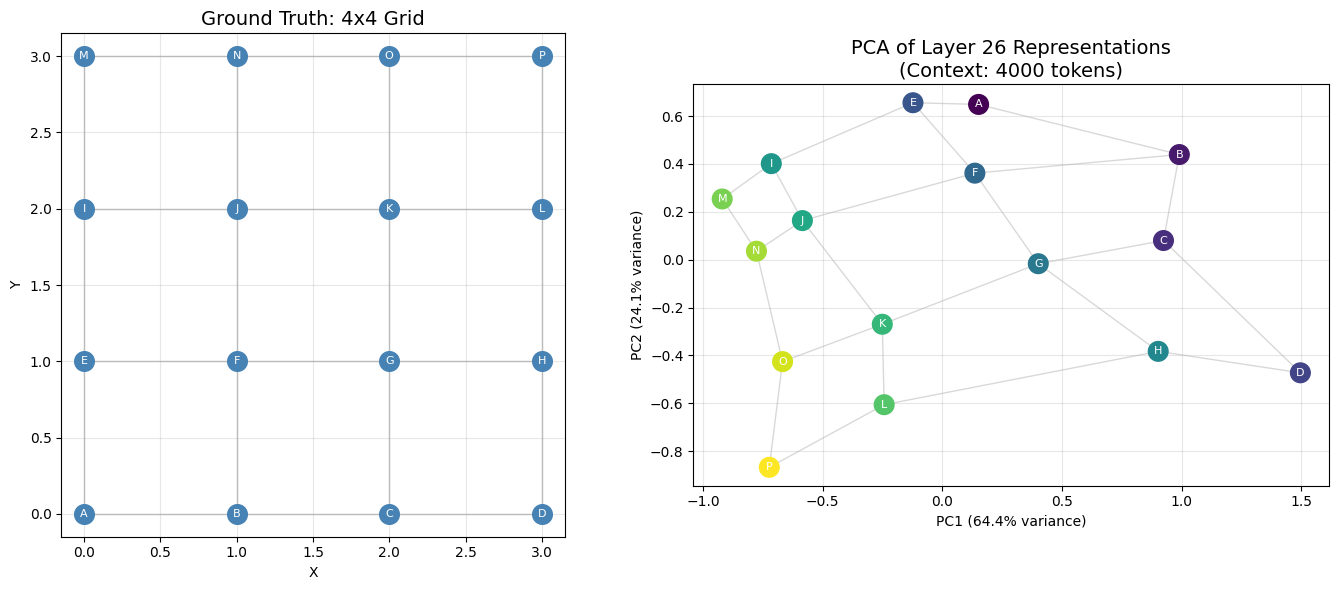


Saved visualization to outputs/random_walk_pca_layer26.png


In [167]:
# --- Visualize PCA projection alongside the grid structure ---

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Ground truth grid structure
ax1 = axes[0]
ax1.set_title(f"Ground Truth: {GRID_SIZE}x{GRID_SIZE} Grid", fontsize=14)

# Draw grid nodes at their actual positions
for node in graph.nodes():
    x = node % GRID_SIZE
    y = node // GRID_SIZE
    ax1.scatter(x, y, s=200, c='steelblue', zorder=2)
    ax1.annotate(CONCEPTS[node][:4], (x, y), ha='center', va='center', fontsize=8, color='white') #, fontweight='bold')

# Draw edges
for (u, v) in graph.edges():
    x1, y1 = u % GRID_SIZE, u // GRID_SIZE
    x2, y2 = v % GRID_SIZE, v // GRID_SIZE
    ax1.plot([x1, x2], [y1, y2], 'gray', alpha=0.5, linewidth=1, zorder=1)

ax1.set_xlabel("X")
ax1.set_ylabel("Y")
ax1.set_aspect('equal')
ax1.grid(True, alpha=0.3)

# Plot 2: PCA projection of representations
ax2 = axes[1]
ax2.set_title(f"PCA of Layer {actual_layer} Representations\n(Context: {WALK_LENGTH} tokens)", fontsize=14)

# Color by grid position
colors = [node / graph.number_of_nodes() for node in range(graph.number_of_nodes())]
scatter = ax2.scatter(pca_result[:, 0], pca_result[:, 1], c=colors, cmap='viridis', s=200, zorder=2)

# Annotate with concept names
for i, concept in enumerate(concept_names):
    ax2.annotate(concept[:4], (pca_result[i, 0], pca_result[i, 1]), 
                ha='center', va='center', fontsize=8, color='white') #, fontweight='bold')

# Draw edges based on graph connectivity
for (u, v) in graph.edges():
    idx_u = CONCEPTS.index(CONCEPTS[u])
    idx_v = CONCEPTS.index(CONCEPTS[v])
    ax2.plot([pca_result[idx_u, 0], pca_result[idx_v, 0]], 
             [pca_result[idx_u, 1], pca_result[idx_v, 1]], 
             'gray', alpha=0.3, linewidth=1, zorder=1)

ax2.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
ax2.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
ax2.set_aspect('equal')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/random_walk_pca_layer26.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nSaved visualization to outputs/random_walk_pca_layer26.png")


In [24]:
result['layer_representations'].shape

(1401, 4096)